In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [5]:
df_train = pd.read_csv(r"C:\Suren\Academmics\6th sem\AI & EDGE COMPUTING\Lab\Data Sets\Week 12-15\train_numeric.csv", nrows=10000)

In [7]:
df_train.shape

(10000, 970)

In [9]:
df_train.head(5)

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
0,4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [11]:
import pandas as pd
indices = df_train.index[df_train.Response ==1].tolist()
display(df_train.loc[indices[:4]])

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
539,1053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
633,1250,0.075,0.101,-0.179,-0.216,-0.013,0.070,-0.022,-0.152,0.087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
681,1350,0.069,0.041,0.330,0.330,-0.100,-0.294,0.008,0.088,-0.092,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
887,1793,0.003,-0.026,0.330,0.294,0.074,0.161,0.022,0.128,-0.199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [13]:
# Drop columns with more than 30% missing values:
# The dataset has many missing values, and some columns have more than 70% missing values.
# We drop these columns using a threshold of 30% missing values.
missing_values = df_train.isnull().sum() / len(df_train)
cols_to_drop = missing_values[missing_values > 0.3].index
df_train = df_train.drop(cols_to_drop, axis=1)

In [15]:
df_train.shape
(10000, 109)

(10000, 109)

In [17]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(df_train.drop(['Response'], axis=1))
y = df_train['Response']

In [19]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [23]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=2)

In [24]:
RandomForestClassifier(max_depth=10, random_state=2)

RandomForestClassifier(max_depth=10, random_state=2)

In [25]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Accuracy: {:.2f}%'.format(acc * 100))

Accuracy: 99.45%


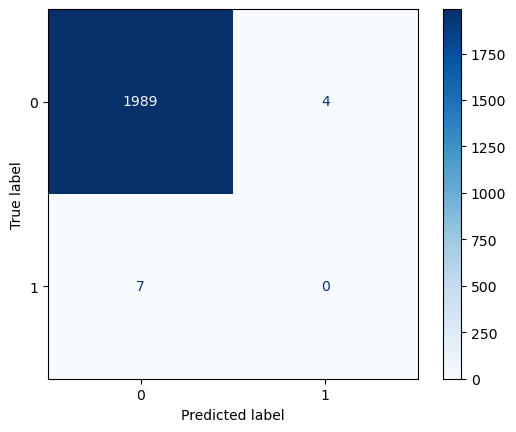

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [41]:
!pip install xgboost
import xgboost as xgb

clf = xgb.XGBClassifier(max_depth=10, learning_rate=0.1, n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [35]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [37]:
print('Accuracy: {:.2f}%'.format(acc * 100))

Accuracy: 99.40%


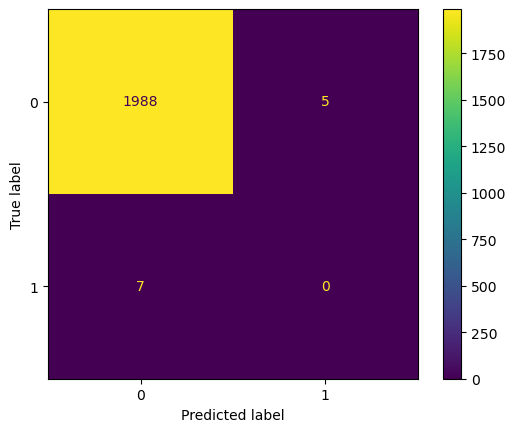

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming clf is your trained model
y_pred = clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()